<a href="https://colab.research.google.com/github/tatyanakrivonogova/machine-learning-methods/blob/master/%D0%91%D0%BB%D0%BE%D0%BA_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Нейронная сеть прямого распространения (регрессия)
Модель - многослойный перцептрон, состоящий из последовательно соединённых полносвязных слоёв. Обучение выполняется с использованием алгоритма обратного распространения ошибки и оптимизатора Adam. Сеть аппроксимирует нелинейную зависимость между входными признаками и непрерывной целевой переменной, минимизируя среднеквадратичную ошибку (MSE).

### Используемые библиотеки

In [184]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neural_network import MLPRegressor

### Датасет

In [185]:
data = fetch_california_housing()
X = data.data
y = data.target
feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['MedHouseVal'] = y

print("Размер:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

Размер: (20640, 9)

Первые 5 строк:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


### Предварительная обработка датасета

In [186]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Размер обучающей выборки:", X_train_scaled.shape)
print("Размер тестовой выборки:", X_test_scaled.shape)

Размер обучающей выборки: (16512, 8)
Размер тестовой выборки: (4128, 8)


### Тепловая карта

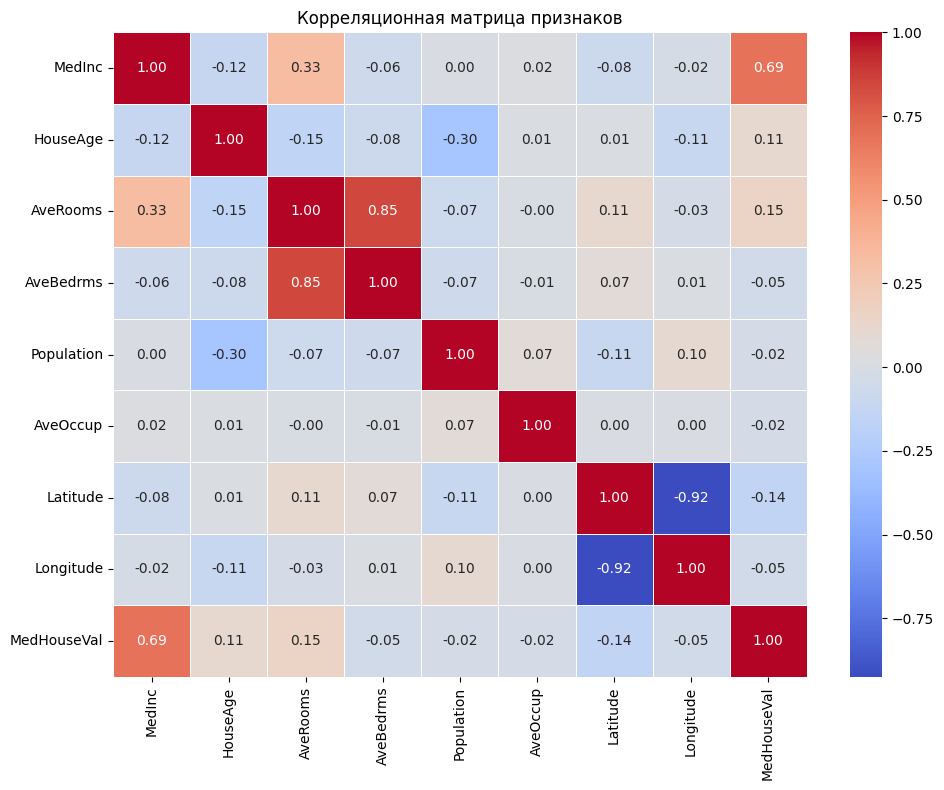

In [187]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

### Обучение модели

In [188]:
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import uniform, randint

# mlp = MLPRegressor(
#     random_state=42,
#     max_iter=100,
#     early_stopping=True,
#     validation_fraction=0.1,
#     verbose=False
# )

# param_dist = {
#     'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (64, 32, 16)],
#     'activation': ['relu', 'tanh', 'logistic'],
#     'solver': ['adam', 'sgd'],
#     'alpha': uniform(1e-5, 1e-2),
#     'learning_rate_init': uniform(1e-4, 1e-2),
#     'batch_size': randint(16, 128),
#     'learning_rate': ['constant', 'adaptive']
# }

# random_search = RandomizedSearchCV(
#     estimator=mlp,
#     param_distributions=param_dist,
#     n_iter=50,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     random_state=42,
#     verbose=1
# )

# random_search.fit(X_train_scaled, y_train)

# print("Лучшие параметры:", random_search.best_params_)
# print("Лучшее значение MSE на кросс-валидации:", -random_search.best_score_)

In [189]:
model = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='tanh',
    solver='adam',
    alpha=0.0038,
    batch_size=105,
    learning_rate_init=0.0069,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.2,
    random_state=42
)

model.fit(X_train_scaled, y_train)

MLPRegressor(activation='tanh', alpha=0.0038, batch_size=105,
             early_stopping=True, hidden_layer_sizes=(64, 32, 16),
             learning_rate_init=0.0069, random_state=42,
             validation_fraction=0.2)

### Прогнозы модели

In [190]:
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

MSE: 0.2631
MAE: 0.3449
R2: 0.7992


### Графики выходных результатов

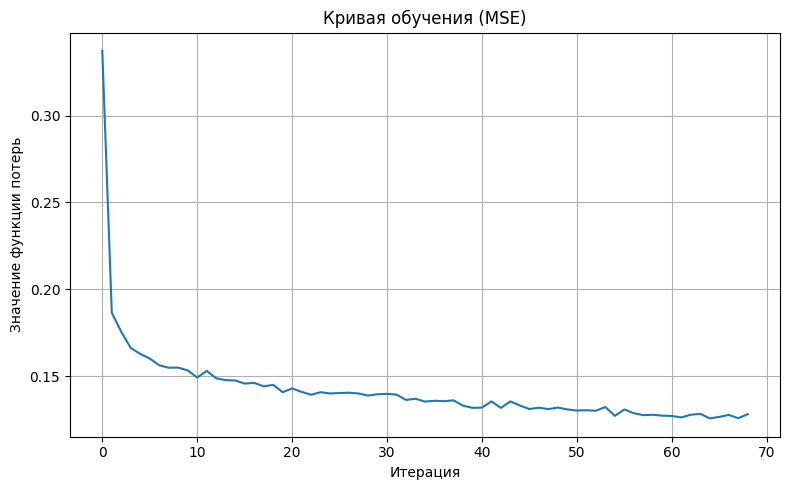

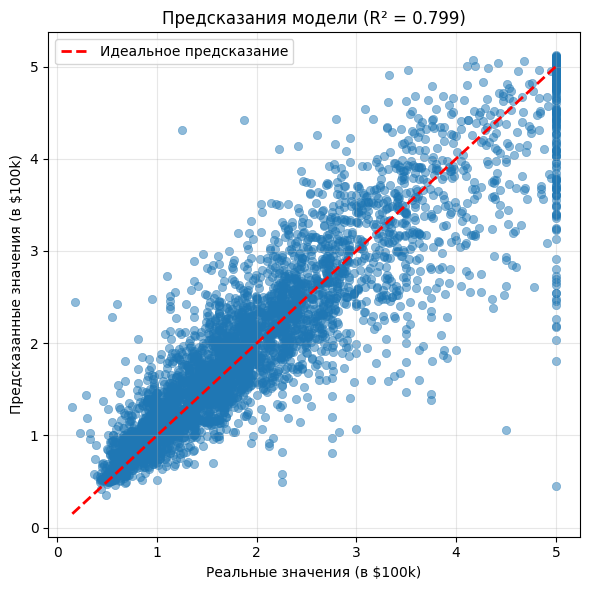

In [191]:
train_loss = model.loss_curve_
plt.figure(figsize=(8, 5))
plt.plot(train_loss)
plt.xlabel('Итерация')
plt.ylabel('Значение функции потерь')
plt.title('Кривая обучения (MSE)')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Реальные значения (в $100k)')
plt.ylabel('Предсказанные значения (в $100k)')
plt.title(f'Предсказания модели (R² = {r2:.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()